# SAAS CHURN SIGNAL SYSTEM 🚀📊


**PROJECT OVERVIEW** 📋
----------------
This notebook explores customer churn patterns 📈
for a SaaS subscription business using the IBM
Telco Customer Churn dataset.

**DATASET** 💾
-------
**Source**      : IBM Telco Customer Churn (Kaggle) https://www.kaggle.com/datasets/blastchar/telco-customer-churn 🔗

**Rows**        : 7,043 customers 👥

**Columns**     : 21 features 🏷️


**Target**      : Churn (Yes/No) ⚠️


**KEY METRICS TRACKED** 📊
-------------------
- Overall Churn Rate 📊
- Churned **MRR** (Monthly Recurring Revenue lost) 💸
- Churn by Contract Type, Tenure, Payment Method 🔍
- Feature correlations with churn 📉


# **Imports + Load Data**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [40]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_csv('telco_churn.csv')


print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst look:")
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First look:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **Data Cleaning**

In [41]:
print(df.dtypes)
print("\nSummary of types:")
print(df.dtypes.value_counts())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Summary of types:
object     18
int64       2
float64     1
Name: count, dtype: int64


In [42]:
df['TotalCharges'] # should be numeric

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.5
7039,7362.9
7040,346.45
7041,306.6


In [43]:
# Fix 1 — Convert TotalCharges to numeric (spaces become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("TotalCharges dtype now:", df['TotalCharges'].dtype)

TotalCharges dtype now: float64


In [44]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [45]:
# Fix 2 — Drop the 11 problem rows (new customers, no billing history)
df = df.dropna(subset=['TotalCharges'])
print("Shape after dropping:", df.shape)

Shape after dropping: (7032, 21)


In [46]:
df['Churn']# Fix 3
# Should be numeric/Binary ( For ML Modelling)

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [47]:
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nOverall churn rate: {df['Churn_Binary'].mean()*100:.2f}%")


Churn distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Overall churn rate: 26.58%


In [48]:
# — Create tenure buckets
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26, 39])

In [50]:
df['tenure_bucket'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
)
print("\nTenure bucket distribution:")
print(df['tenure_bucket'].value_counts().sort_index())


Tenure bucket distribution:
tenure_bucket
0-12 months     2175
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64


# **Null Check (After Cleaning)**

In [54]:
print("Null check across all columns:")
null_summary = df.isnull().sum()
print(null_summary[null_summary > 0])
total_nulls = df.isnull().sum().sum()
print(f"\nTotal nulls remaining: {total_nulls}")
print(f"Dataset is {((1 - total_nulls/(df.shape[0]*df.shape[1]))*100):.2f}% complete")

Null check across all columns:
Series([], dtype: int64)

Total nulls remaining: 0
Dataset is 100.00% complete


# **Descriptive Statistics**

In [55]:
print("Descriptive statistics:")
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)

Descriptive statistics:


,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


Reports folder created!


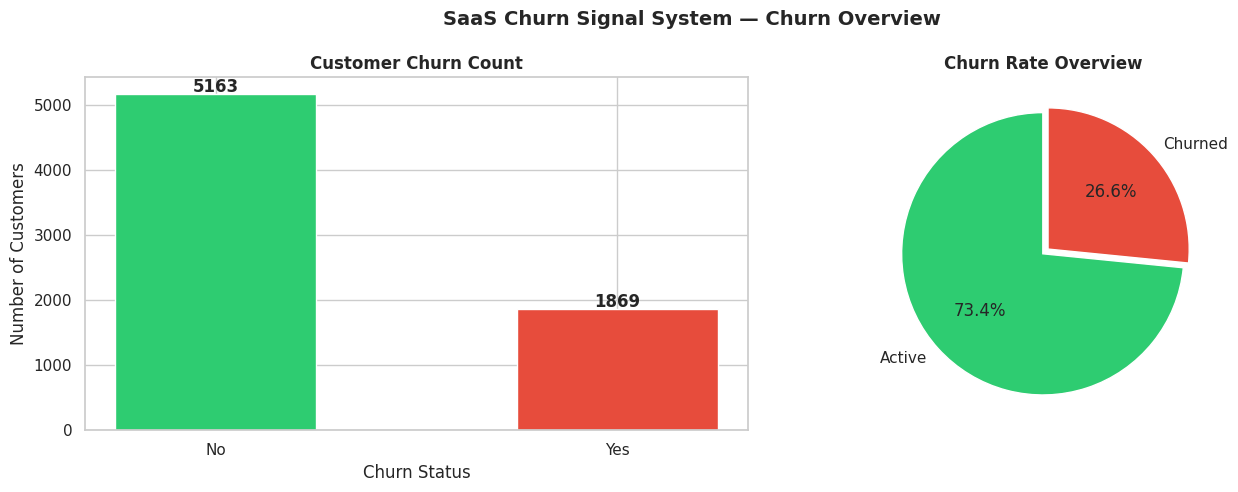

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
churn_counts = df['Churn'].value_counts()
axes[0].bar(
    churn_counts.index,
    churn_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white', width=0.5
)
axes[0].set_title('Customer Churn Count', fontweight='bold')
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    churn_counts.values,
    labels=['Active', 'Churned'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_title('Churn Rate Overview', fontweight='bold')

plt.suptitle('SaaS Churn Signal System — Churn Overview',
             fontsize=14, fontweight='bold')
plt.tight_layout()

import os
os.makedirs('reports', exist_ok=True)
print("Reports folder created!")
plt.savefig('../reports/01_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### **How churn rate changes with contract type, tenure, and payment method.**



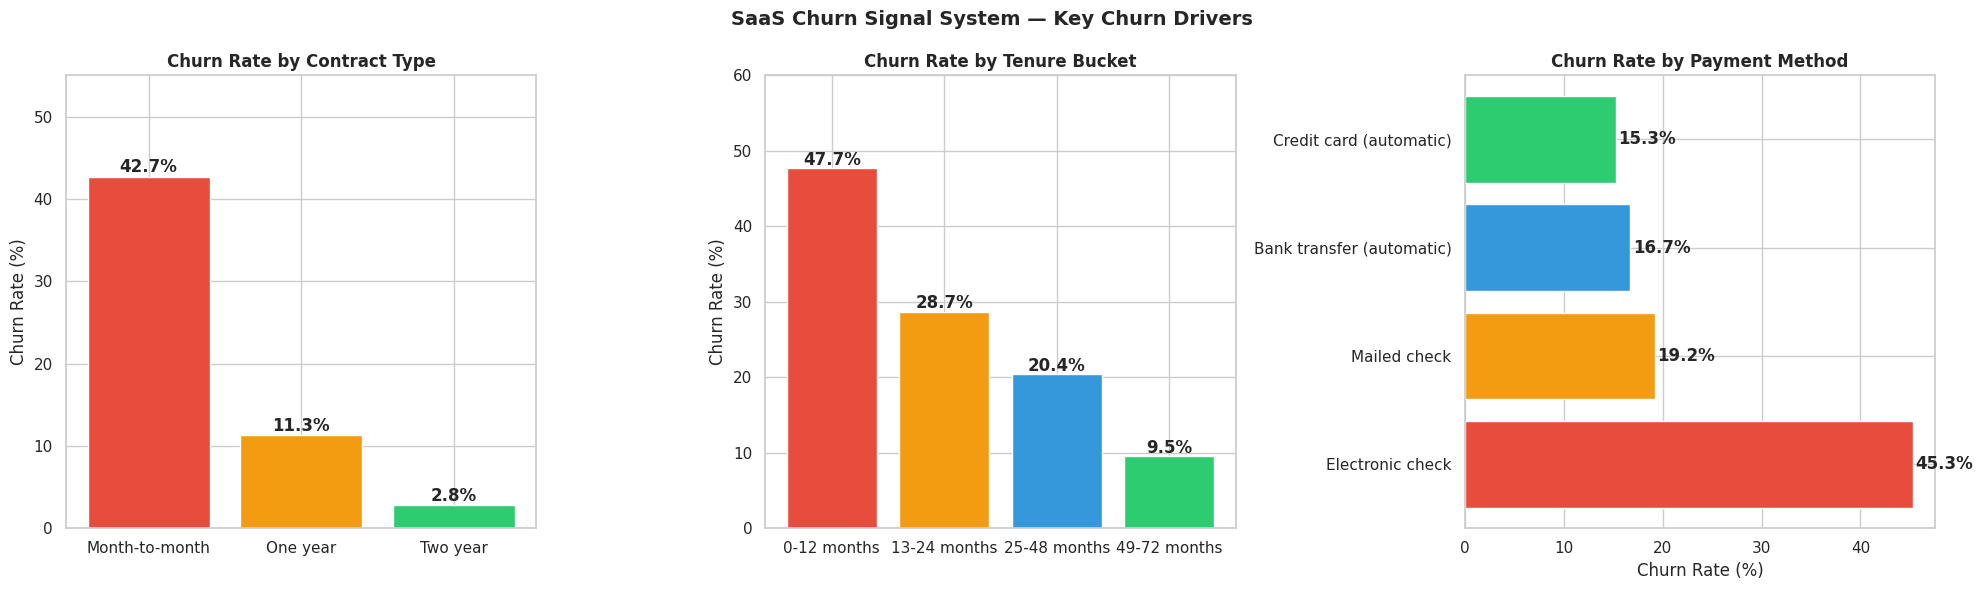

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Contract type
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
contract_churn = contract_churn.sort_values(ascending=False)
bars = axes[0].bar(contract_churn.index, contract_churn.values,
                   color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 55)
for bar, val in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Tenure bucket
tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn_Binary'].mean() * 100
bars2 = axes[1].bar(tenure_churn.index, tenure_churn.values,
                    color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'],
                    edgecolor='white')
axes[1].set_title('Churn Rate by Tenure Bucket', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 60)
for bar, val in zip(bars2, tenure_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Payment method
payment_churn = df.groupby('PaymentMethod')['Churn_Binary'].mean() * 100
payment_churn = payment_churn.sort_values(ascending=False)
bars3 = axes[2].barh(payment_churn.index, payment_churn.values,
                     color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'],
                     edgecolor='white')
axes[2].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[2].set_xlabel('Churn Rate (%)')
for bar, val in zip(bars3, payment_churn.values):
    axes[2].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold')

plt.suptitle('SaaS Churn Signal System — Key Churn Drivers',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/02_churn_by_features.png', dpi=150, bbox_inches='tight')
plt.show()

## **Correlation Heatmap**
How strongly each numeric column is related to churn

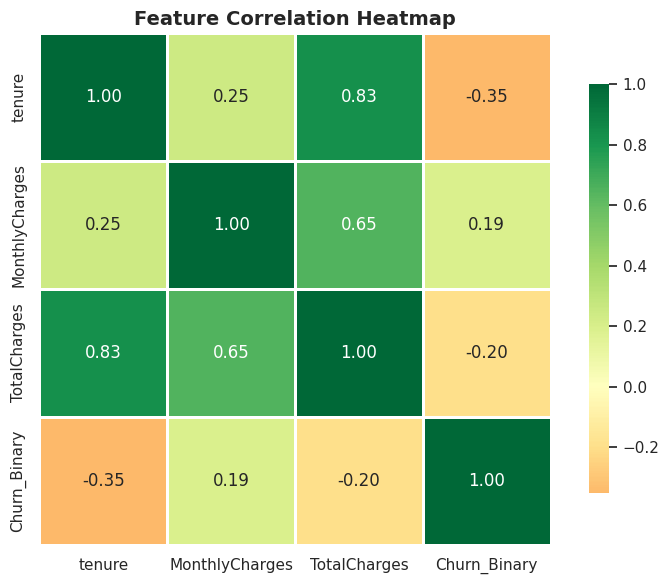

Correlation with Churn:
tenure           -0.354049
TotalCharges     -0.199484
MonthlyCharges    0.192858
Churn_Binary      1.000000
Name: Churn_Binary, dtype: float64


In [64]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    square=True, linewidths=1,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the churn correlations specifically
print("Correlation with Churn:")
print(corr_matrix['Churn_Binary'].sort_values())


Avg MonthlyCharges — Churned: $74.44
Avg MonthlyCharges — Active:  $61.31


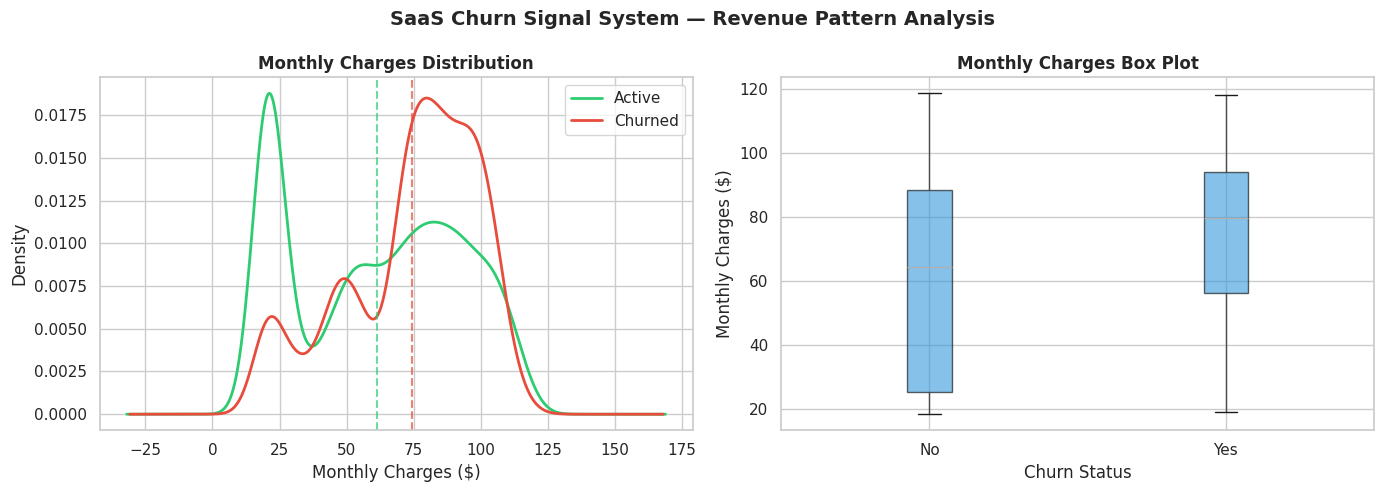

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
df[df['Churn']=='No']['MonthlyCharges'].plot(
    kind='kde', ax=axes[0], color='#2ecc71', linewidth=2, label='Active')
df[df['Churn']=='Yes']['MonthlyCharges'].plot(
    kind='kde', ax=axes[0], color='#e74c3c', linewidth=2, label='Churned')
axes[0].set_title('Monthly Charges Distribution', fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].legend()

avg_churned = df[df['Churn']=='Yes']['MonthlyCharges'].mean()
avg_active  = df[df['Churn']=='No']['MonthlyCharges'].mean()
axes[0].axvline(avg_churned, color='#e74c3c', linestyle='--', alpha=0.7)
axes[0].axvline(avg_active,  color='#2ecc71', linestyle='--', alpha=0.7)

# Box plot
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1].set_title('Monthly Charges Box Plot', fontweight='bold')
axes[1].set_xlabel('Churn Status')
axes[1].set_ylabel('Monthly Charges ($)')
plt.suptitle('')

print(f"Avg MonthlyCharges — Churned: ${avg_churned:.2f}")
print(f"Avg MonthlyCharges — Active:  ${avg_active:.2f}")

plt.suptitle('SaaS Churn Signal System — Revenue Pattern Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/04_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()


In [66]:
# AUTHOR  : Seenu
# PROJECT : SaaS Churn Signal System